# Prediction task - House Prices
# Completed as part of the coursework for the Data Mining and Knowledge Discovery in Data module at the University of Brighton, 2025/26.

## Gosia Szkatula

## 11/06/2026

Run time is approximately 2 hours.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_regression,
    mutual_info_regression, RFE, SequentialFeatureSelector)
from scipy import stats

# 2. Methodology

## 2.1.1 Data overview

In [113]:
# download dataset
data = pd.read_csv("../data/Houses_price_dataset.csv")
# view dataset
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340.0,5650.0
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690.0,7639.0
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720.0,8062.0
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360.0,5000.0
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800.0,7503.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21609,6600060120,20150223T000000,400000,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830.0,7200.0
21610,1523300141,20140623T000000,402101,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020.0,2007.0
21611,291310100,20150116T000000,400000,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410.0,1287.0
21612,1523300157,20141015T000000,325000,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020.0,1357.0


In [98]:
# datatype
type(data)

pandas.DataFrame

In [115]:
data.dtypes

id                 int64
date                 str
price              int64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
dtype: object

## 2.1.2 Data cleaning

Identified in part 1.

In [99]:
# fix error
data.loc[data["bedrooms"] == 33, "bedrooms"] = 3

# missing values
data["sqft_living15"] = data["sqft_living15"].fillna(data["sqft_living15"].median())
data["sqft_lot15"] = data["sqft_lot15"].fillna(data["sqft_lot15"].median())

## 2.2.1 Feature engineering

In [100]:
# sale_month
data["date"] = pd.to_datetime(data["date"], format="%Y%m%dT%H%M%S")
data["sale_month"] = data["date"].dt.month

# is_renovated
data["is_renovated"] = (data["yr_renovated"] > 0).astype(int)

# years_since_renovation
data["years_since_renovation"] = (
    data["date"].dt.year - data["yr_renovated"]
)
data.loc[data["yr_renovated"] == 0, "years_since_renovation"] = 0

# has_basement
data["has_basement"] = (data["sqft_basement"] > 0).astype(int)

# house_age
data['house_age'] = pd.to_datetime(data['date']).dt.year - data['yr_built']

## 2.1.3 Class balance assessment

In [101]:
data["sale_month"].value_counts()

sale_month
5     2414
4     2231
7     2211
6     2180
8     1940
10    1879
3     1875
9     1774
12    1471
11    1411
2     1250
1      978
Name: count, dtype: int64

In [102]:
data["waterfront"].value_counts()

waterfront
0    21451
1      163
Name: count, dtype: int64

In [103]:
data["has_basement"].value_counts()

has_basement
0    13127
1     8487
Name: count, dtype: int64

In [104]:
data["is_renovated"].value_counts()

is_renovated
0    20700
1      914
Name: count, dtype: int64

## 2.2.2 Log transformations

In [105]:
def add_log_features(df):
    df = df.copy()

    for col in [
        "sqft_living",
        "sqft_lot",
        "sqft_above",
        "sqft_living15",
        "sqft_lot15"
    ]:
        df[f"log_{col}"] = np.log(df[col].clip(lower=1))

    df["log_sqft_basement"] = np.log1p(df["sqft_basement"])

    return df

data = add_log_features(data)


## 2.2.3 Redundant feature removal

In [106]:
cols_to_drop = [
    "id", "date", "yr_built", "yr_renovated",
    "zipcode",
    "sqft_living", "sqft_lot", "sqft_above",
    "sqft_basement", "sqft_living15", "sqft_lot15"
]

data = data.drop(columns=cols_to_drop, errors="ignore")

Check feature matrix at this point

In [107]:
data.dtypes

price                       int64
bedrooms                    int64
bathrooms                 float64
floors                    float64
waterfront                  int64
view                        int64
condition                   int64
grade                       int64
lat                       float64
long                      float64
sale_month                  int32
is_renovated                int64
years_since_renovation      int64
has_basement                int64
house_age                   int64
log_sqft_living           float64
log_sqft_lot              float64
log_sqft_above            float64
log_sqft_living15         float64
log_sqft_lot15            float64
log_sqft_basement         float64
dtype: object

## 2.2.4 Train-test split

In [108]:
X = data.drop(columns=["price"])
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# log transform target
y_train = np.log(y_train)
y_test = np.log(y_test)

## 2.2.5 Scaling

In [109]:
scaler = StandardScaler()

cols_to_scale = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_above',
    'log_sqft_basement', 'log_sqft_living15', 'log_sqft_lot15',
    'bedrooms', 'bathrooms', 'floors', 'house_age',
    'grade', 'view', 'condition'
]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 2.4 Feature selection

## 2.4.1 Procedures

In [57]:
X_fs = X_train.copy()
y_fs = y_train.copy()

# variance
var = VarianceThreshold(0.01).fit(X_fs)
feat_var = pd.Series(var.get_support(), index=X_fs.columns)

# correlation
corr = X_fs.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr = [col for col in upper.columns if any(upper[col] > 0.8)]
feat_corr = pd.Series([col not in drop_corr for col in X_fs.columns], index=X_fs.columns)

# ANOVA
anova = SelectKBest(f_regression, k=10).fit(X_fs, y_fs)
feat_anova = pd.Series(anova.get_support(), index=X_fs.columns)

# mutual information
mi = mutual_info_regression(X_fs, y_fs)
top = np.argsort(mi)[-10:]
feat_mi = pd.Series([i in top for i in range(len(X_fs.columns))], index=X_fs.columns)

# lasso
lasso = LassoCV(cv=5, random_state=42).fit(X_fs, y_fs)
feat_lasso = pd.Series(lasso.coef_ != 0, index=X_fs.columns)

# ridge
ridge = RidgeCV(cv=5).fit(X_fs, y_fs)
feat_ridge = pd.Series(np.abs(ridge.coef_) > 0.01, index=X_fs.columns)

# random forest
rf = RandomForestRegressor().fit(X_fs, y_fs)
imp = rf.feature_importances_
top_rf = imp.argsort()[-10:]
feat_rf = pd.Series([i in top_rf for i in range(len(X_fs.columns))], index=X_fs.columns)

# combine
fs_table = pd.concat(
    [feat_var, feat_corr, feat_anova, feat_mi, feat_lasso, feat_ridge, feat_rf],
    axis=1
)

fs_table = pd.concat(
    [feat_var, feat_corr, feat_anova, feat_mi, feat_lasso, feat_ridge, feat_rf],
    axis=1
)
fs_table.columns = ['Variance', 'Correlation', 'ANOVA', 'Mutual Information', 'Lasso', 'Ridge', 'Random Forest']

fs_table

,Variance,Correlation,ANOVA,Mutual Information,Lasso,Ridge,Random Forest
bedrooms,True,True,True,True,True,True,False
bathrooms,True,True,True,True,True,True,False
floors,True,True,True,False,True,True,False
waterfront,False,True,False,False,True,True,False
view,True,True,True,False,True,True,True
condition,True,True,False,False,True,True,False
grade,True,True,True,True,True,True,True
lat,True,True,True,True,True,True,True
long,True,True,False,True,False,True,True
sale_month,True,True,False,False,True,False,False


## 2.4.2 Selection criteria

In [58]:
votes = fs_table.sum(axis=1)

# 1. RF-based
feature_rf = fs_table.index[feat_rf]

# 2. strict voting (≥6)
feature_v6 = votes[votes >= 6].index

# 3. moderate voting (≥4)
feature_v4 = votes[votes >= 4].index

In [59]:
feature_sets = {
    "rf": feature_rf,
    "v6": feature_v6,
    "v4": feature_v4
}

In [60]:
models = {
    "lr": LinearRegression(),
    "rf": RandomForestRegressor(random_state=42),
    "gbr": GradientBoostingRegressor(random_state=42),
    "mlp": MLPRegressor(random_state=42),
    "stack": StackingRegressor(
        estimators=[
            ("lr", LinearRegression()),
            ("rf", RandomForestRegressor(random_state=42)),
            ("gbr", GradientBoostingRegressor(random_state=42))
        ],
        final_estimator=LinearRegression()
    )
}

## 2.4.3 Feature set evaluation

In [61]:
results = []
for fname, fcols in feature_sets.items():
    X_tr = X_train[fcols]  # train data
    

    for mname, model in models.items():
        model.fit(X_tr, y_train)
        preds = model.predict(X_tr)         # train data
        rmse = np.sqrt(mean_squared_error(y_train, preds))  # train data
        results.append({
            "model": mname,
            "feature_set": fname,
            "RMSE": rmse
        })

results_fs = pd.DataFrame(results).sort_values("RMSE")
results_fs

,model,feature_set,RMSE
11,rf,v4,0.068444
1,rf,rf,0.068815
6,rf,v6,0.080777
14,stack,v4,0.102656
4,stack,rf,0.104140
9,stack,v6,0.130257
12,gbr,v4,0.181273
2,gbr,rf,0.182693
7,gbr,v6,0.201932
10,lr,v4,0.253465


In [62]:
best_per_model = results_fs.loc[results_fs.groupby("model")["RMSE"].idxmin()]
best_per_model

,model,feature_set,RMSE
12,gbr,v4,0.181273
10,lr,v4,0.253465
3,mlp,rf,0.287459
11,rf,v4,0.068444
14,stack,v4,0.102656


# 2.6 Model Building & Optimasation

## 2.6.1 Model training

In [63]:
X_train_final = X_train[feature_v4]
X_test_final = X_test[feature_v4]

for model in models.values():
    model.fit(X_train_final, y_train)

Hypertuning - see below (results included)

# 3 Results

## 3.1 Model Evaluation (untuned, test data)

In [64]:
# make sure stack is fitted in your baseline models dictionary
models = {
    "lr": LinearRegression(),
    "rf": RandomForestRegressor(random_state=42),
    "gbr": GradientBoostingRegressor(random_state=42),
    "mlp": MLPRegressor(random_state=42),
    "stack": StackingRegressor(
        estimators=[
            ("lr", LinearRegression()),
            ("rf", RandomForestRegressor(random_state=42)),
            ("gbr", GradientBoostingRegressor(random_state=42))
        ],
        final_estimator=LinearRegression()
    )
}

for model in models.values():
    model.fit(X_train_final, y_train)

# baseline evaluation
results = []  # initialise here
n = X_test_final.shape[0]
p = X_test_final.shape[1]

for name, model in models.items():
    preds = model.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
    cv_scores = cross_val_score(model, X_train_final, y_train, 
                                cv=5, scoring="r2")
    cv_mean = round(cv_scores.mean(), 3)
    cv_std = round(cv_scores.std(), 3)
    
    results.append({
        "model": name,
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
        "Adj_R2": round(r2_adj, 3),
        "CV_R2_mean": cv_mean,
        "CV_R2_std": cv_std
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,model,RMSE,R2,Adj_R2,CV_R2_mean,CV_R2_std
4,stack,0.171,0.895,0.895,0.885,0.004
1,rf,0.174,0.891,0.891,0.880,0.004
2,gbr,0.184,0.879,0.879,0.869,0.006
0,lr,0.255,0.768,0.767,0.767,0.008
3,mlp,0.302,0.673,0.671,0.679,0.022


## 2.6.2 Hyperparameter tuning (Test data)

In [ ]:
lr_params = {
    'fit_intercept': [True, False]
}
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
gbr_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_leaf': [20, 50, 100],
    'subsample': [0.6, 0.8, 1.0]
}
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100), (200, 100)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [200, 500, 1000]
}

search_lr = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
search_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gbr_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
search_mlp = GridSearchCV(
    MLPRegressor(random_state=42),
    mlp_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

search_lr.fit(X_train_final, y_train)
search_rf.fit(X_train_final, y_train)
search_gbr.fit(X_train_final, y_train)
search_mlp.fit(X_train_final, y_train)

best_lr = search_lr.best_estimator_
best_rf = search_rf.best_estimator_
best_gbr = search_gbr.best_estimator_
best_mlp = search_mlp.best_estimator_

GridSearchCV-selected hyperparameters (non-default)

In [67]:
print(best_lr.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


In [86]:
print(best_rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [89]:
print(best_gbr.get_params())

{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'squared_error', 'max_depth': 6, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 50, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 500, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.8, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [90]:
print(best_mlp.get_params())

{'activation': 'tanh', 'alpha': 0.001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'loss': 'squared_error', 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


## 3.1 Model Evaluation (tuned, test data)

In [72]:
best_model = best_gbr
preds = best_model.predict(X_test_final)


In [73]:
# build stacking model using best estimators
best_stack = StackingRegressor(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("gbr", best_gbr)
    ],
    final_estimator=LinearRegression()
)
best_stack.fit(X_train_final, y_train)

# collect all tuned models
tuned_models = {
    "lr": best_lr,
    "rf": best_rf,
    "gbr": best_gbr,
    "mlp": best_mlp,
    "stack": best_stack
}

# evaluate on test set
results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    n = len(y_test)
    p = X_test_final.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    cv_scores = cross_val_score(model, X_train_final, y_train, cv=5, scoring="r2")
    cv_mean = round(cv_scores.mean(), 3)   
    cv_std = round(cv_scores.std(), 3)     
    results.append({
        "model": name,
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
        "Adj_R2": round(adj_r2, 3),
        "CV_R2_mean": cv_mean,
        "CV_R2_std": cv_std
    })

# build and display table
results_tuned = pd.DataFrame(results).sort_values("RMSE")
results_tuned

,model,RMSE,R2,Adj_R2,CV_R2_mean,CV_R2_std
2,gbr,0.162,0.906,0.906,0.898,0.005
4,stack,0.162,0.906,0.906,0.898,0.005
1,rf,0.177,0.887,0.887,0.878,0.005
3,mlp,0.249,0.778,0.777,0.775,0.020
0,lr,0.255,0.768,0.767,0.767,0.008


## 3.3 Validation 

On the best model = Gradient Boost

### Figure. Feature Importance

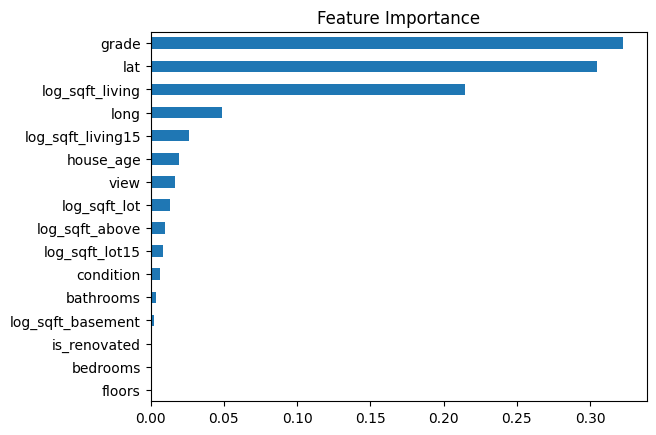

In [74]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train_final.columns
).sort_values()

feat_imp.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

### Figure. Observed vs. Predicted

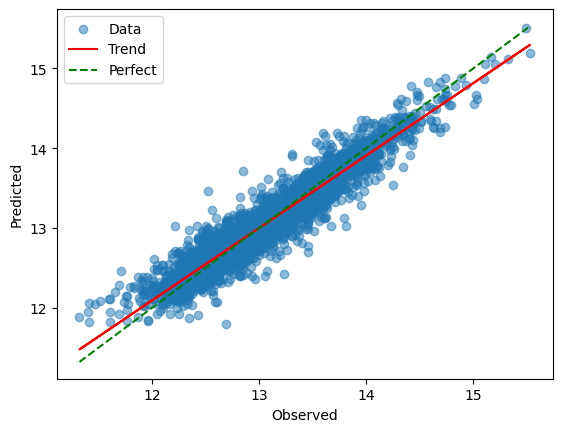

In [75]:
plt.scatter(y_test, preds, alpha=0.5, label="Data")

preds = best_model.predict(X_test_final)
z = np.polyfit(y_test, preds, 1)
p = np.poly1d(z)

plt.plot(y_test, p(y_test), color='red', label='Trend')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='green', label='Perfect')

plt.legend()
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.show()

### Figure. 5-Fold Cross-Validation RMSE Comparison

In [76]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# define folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# store results
rmse_scores = {name: [] for name in models.keys()}

# loop through folds
for train_idx, val_idx in kf.split(X_train_final):

    X_tr = X_train_final.iloc[train_idx]
    X_val = X_train_final.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    for name, model in tuned_models.items():
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmse_scores[name].append(rmse)


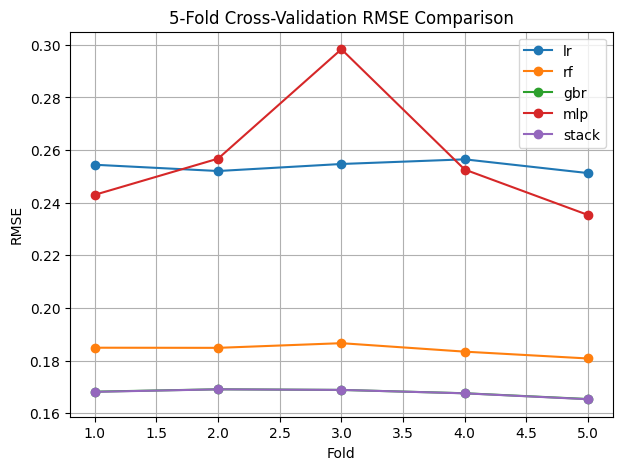

In [77]:
folds = [1, 2, 3, 4, 5]

plt.figure(figsize=(7,5))

for name, scores in rmse_scores.items():
    plt.plot(folds, scores, marker='o', label=name)

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation RMSE Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [78]:
for name, scores in rmse_scores.items():
    print(f"{name} Mean RMSE: {np.mean(scores):.4f}")


lr Mean RMSE: 0.2538
rf Mean RMSE: 0.1841
gbr Mean RMSE: 0.1678
mlp Mean RMSE: 0.2572
stack Mean RMSE: 0.1678


### Figure. Distribution of residuals

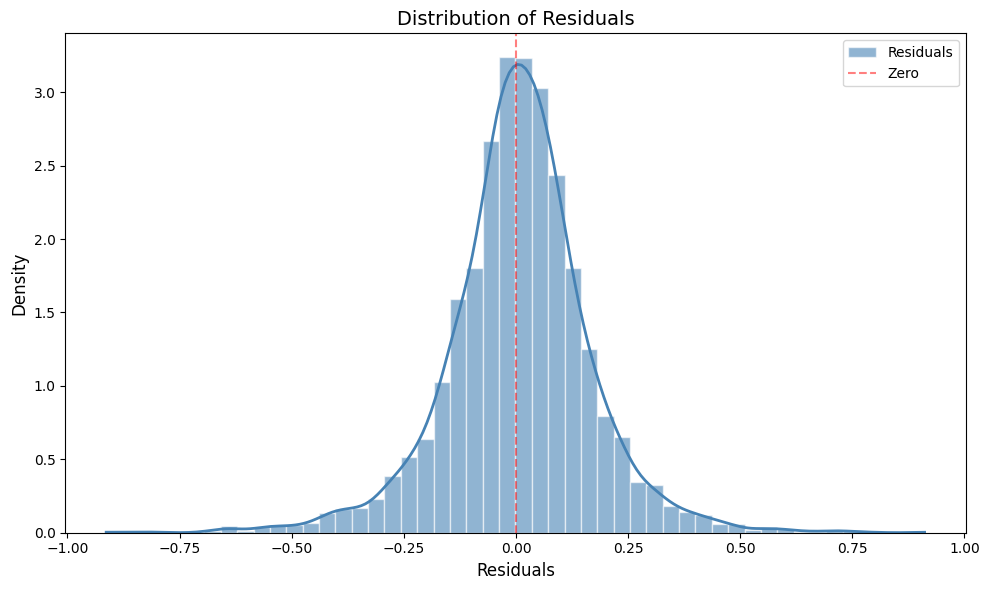

In [94]:
# get residuals from best gbr model
y_pred = best_gbr.predict(X_test_final)
residuals = y_test - y_pred

# plot
fig, ax = plt.subplots(figsize=(10, 6))

# histogram with density
ax.hist(residuals, bins=50, density=True, alpha=0.6, 
        color='steelblue', edgecolor='white', label='Residuals')

# kde curve
kde_x = np.linspace(residuals.min(), residuals.max(), 200)
kde = stats.gaussian_kde(residuals)
ax.plot(kde_x, kde(kde_x), color='steelblue', linewidth=2)

# formatting
ax.set_title('Distribution of Residuals', fontsize=14)
ax.set_xlabel('Residuals', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Zero')
ax.legend()

plt.tight_layout()
plt.show()

In [95]:
# create comparison dataframe
untuned = results_df.set_index('model')['RMSE']
tuned = results_tuned.set_index('model')['RMSE']

improvement = pd.DataFrame({
    'Untuned RMSE': untuned,
    'Tuned RMSE': tuned,
    'Improvement (%)': round(((untuned - tuned) / untuned) * 100, 2)
}).sort_values('Improvement (%)', ascending=False)

print(improvement)

       Untuned RMSE  Tuned RMSE  Improvement (%)
model                                           
mlp           0.302       0.249            17.55
gbr           0.184       0.162            11.96
stack         0.171       0.162             5.26
lr            0.255       0.255             0.00
rf            0.174       0.177            -1.72


### Figure. Percentage change in RMSE following hyperparameter tuning

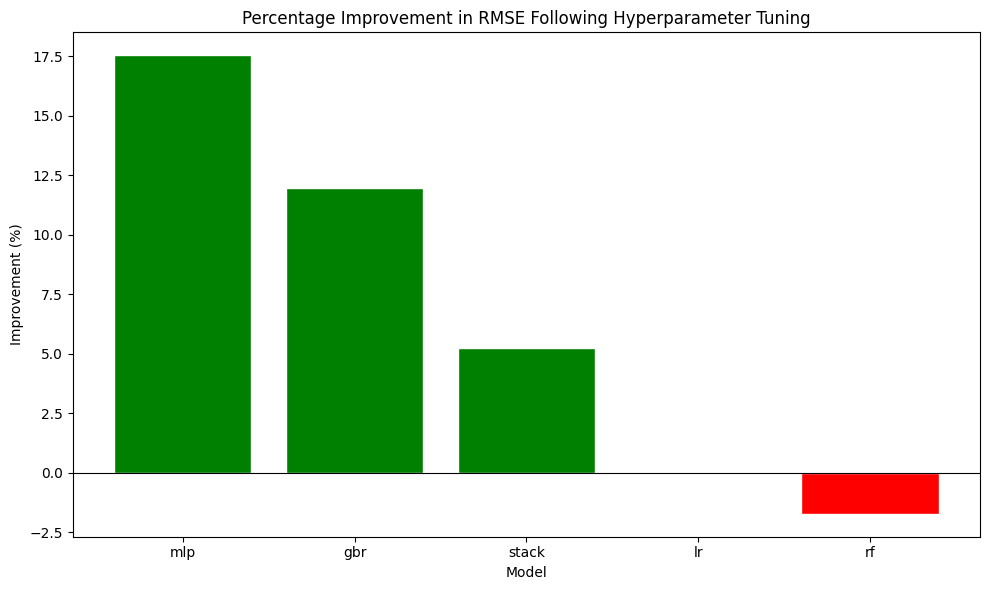

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if x > 0 else 'red' for x in improvement['Improvement (%)']]

ax.bar(improvement.index, improvement['Improvement (%)'], color=colors, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Percentage Improvement in RMSE Following Hyperparameter Tuning')
ax.set_xlabel('Model')
ax.set_ylabel('Improvement (%)')
plt.tight_layout()
plt.show()

# 4. Discussion

In [118]:
# exponentiate both predictions and actual values
y_pred_log = best_gbr.predict(X_test_final)  # predictions on log scale
y_pred_actual = np.expm1(y_pred_log)          # exponentiate predictions back to price scale
y_test_actual = np.expm1(y_test)              # exponentiate actual prices back to price scale  

# calculate RMSE on actual price scale
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print(f"RMSE in dollars: ${rmse_actual:,.0f}")

RMSE in dollars: $114,477


mean house price = 540,075 (reported in A01)

In [122]:
114477/540075*100

21.196500486043604